# <center> <ins> **Steel Defect Detection** </ins> </center>
## <center> https://www.kaggle.com/competitions/severstal-steel-defect-detection/data </center>

# **0. Imports & Config** 

In [4]:
# !pip install -q transformers albumentations segmentation-models-pytorch
# !pip install -q git+https://github.com/facebookresearch/segment-anything.git
# !pip install -q ultralytics
# !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
import os
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import SegformerForSemanticSegmentation, AutoModel
from segment_anything import sam_model_registry
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import segmentation_models_pytorch as smp
from tqdm import tqdm
import torch.optim as optim
import torchvision
from ultralytics import YOLO
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings

In [8]:
TRAIN_DIR = '/kaggle/input/competitions/severstal-steel-defect-detection/train_images'
TRAIN_CSV = '/kaggle/input/competitions/severstal-steel-defect-detection/train.csv'
TEST_DIR = '/kaggle/input/competitions/severstal-steel-defect-detection/test_images'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

USE_AMP = True

print(f"Device: {device}")
print(f"Mixed Precision: {USE_AMP and device == 'cuda'}")


Device: cuda
Mixed Precision: True


# **1. EDA**

In [48]:
def rle_decode(mask_rle, shape=(256, 1600)):
    #run length encoding to binary mask
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
        
    s = mask_rle.split()
    starts = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    
    for low, high in zip(starts, ends):
        img[low:high] = 1
        
    return img.reshape(shape, order='F')

def rle_encode(mask):
    pixels = mask.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

In [8]:
df_raw = pd.read_csv(TRAIN_CSV)

# one row per image
df_pivot = df_raw.pivot(index='ImageId', columns='ClassId', values='EncodedPixels')
df_pivot.columns = [f'Class_{i}' for i in df_pivot.columns]
df_pivot = df_pivot.reset_index()

df_pivot['has_defect'] = df_pivot[['Class_1', 'Class_2', 'Class_3', 'Class_4']].notna().any(axis=1)
df_pivot['num_defects'] = df_pivot[['Class_1', 'Class_2', 'Class_3', 'Class_4']].notna().sum(axis=1)

print(f"Total: {len(df_pivot)}")
print(f"Defect: {df_pivot['has_defect'].sum()} ({df_pivot['has_defect'].mean()*100:.1f}%)")

print("\nClass distribution:")
for i, count in {i: df_pivot[f'Class_{i}'].notna().sum() for i in range(1, 5)}.items():
    print(f"  Class {i}: {count} ({count/len(df_pivot)*100:.2f}%)")

Total: 6666
Defect: 6666 (100.0%)

Class distribution:
  Class 1: 897 (13.46%)
  Class 2: 247 (3.71%)
  Class 3: 5150 (77.26%)
  Class 4: 801 (12.02%)


% defect

Class 1: mean=1.065%, median=0.812%
  Tiny (<0.5%): 268/897 (29.9%)

Class 2: mean=0.825%, median=0.719%
  Tiny (<0.5%): 67/247 (27.1%)

Class 3: mean=6.225%, median=2.918%
  Tiny (<0.5%): 300/5150 (5.8%)

Class 4: mean=8.392%, median=6.191%
  Tiny (<0.5%): 10/801 (1.2%)


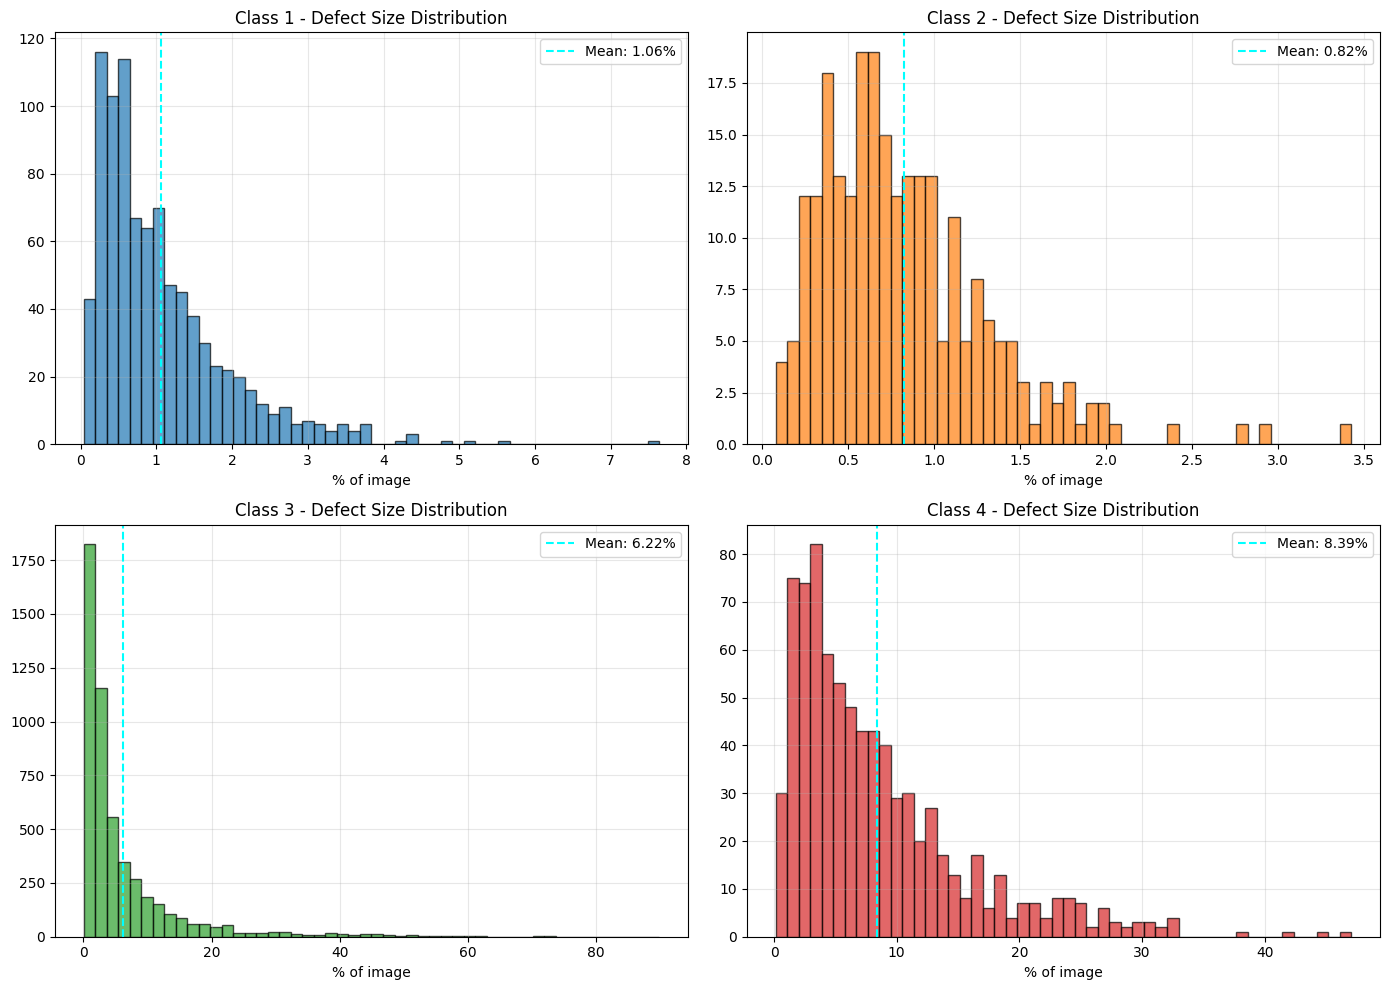

In [9]:
defect_sizes = {i: [] for i in range(1, 5)}
total_pixels = 256 * 1600

for _, row in df_raw.iterrows():
    if not pd.isna(row['EncodedPixels']):
        mask = rle_decode(row['EncodedPixels'])
        pct = (mask.sum() / total_pixels) * 100
        defect_sizes[row['ClassId']].append(pct)

print("% defect")
for i in range(1, 5):
    if defect_sizes[i]:
        sizes = np.array(defect_sizes[i])
        tiny = (sizes < 0.5).sum()
        print(f"\nClass {i}: mean={sizes.mean():.3f}%, median={np.median(sizes):.3f}%")
        print(f"  Tiny (<0.5%): {tiny}/{len(sizes)} ({tiny/len(sizes)*100:.1f}%)")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i in range(1, 5):
    if defect_sizes[i]:
        ax = axes[(i-1)//2, (i-1)%2]
        sizes = np.array(defect_sizes[i])
        ax.hist(sizes, bins=50, color=f'C{i-1}', alpha=0.7, edgecolor='black')
        ax.axvline(sizes.mean(), color='aqua', linestyle='--', label=f'Mean: {sizes.mean():.2f}%')
        ax.set_title(f'Class {i} - Defect Size Distribution')
        ax.set_xlabel('% of image')
        ax.legend()
        ax.grid(alpha=0.3)
        
plt.tight_layout()
plt.savefig('eda_defect_sizes.png', dpi=150)
plt.show()

In [10]:
total_defect_pixels = {i: 0 for i in range(1, 5)}
for _, row in df_raw.iterrows():
    if not pd.isna(row['EncodedPixels']):
        mask = rle_decode(row['EncodedPixels'])
        total_defect_pixels[row['ClassId']] += mask.sum()

total_all_defects = sum(total_defect_pixels.values())
total_background = len(df_pivot) * total_pixels - total_all_defects

print("Per pixel cls imbalance")
print(f"Background: {total_background:,} ({total_background/(len(df_pivot)*total_pixels)*100:.2f}%)")
for i in range(1, 5):
    pct = total_defect_pixels[i] / (len(df_pivot) * total_pixels) * 100
    print(f"Class {i}: {total_defect_pixels[i]:,} ({pct:.3f}%)")

pixel_imbalance = max(total_defect_pixels.values()) / min([v for v in total_defect_pixels.values() if v > 0])
bg_defect_ratio = total_background / total_all_defects
print(f"\nPixel imbalance: {pixel_imbalance:.1f}x")
print(f"Background/Defect ratio: {bg_defect_ratio:.1f}x") 

Per pixel cls imbalance
Background: 2,566,806,529 (94.01%)
Class 1: 3,912,129 (0.143%)
Class 2: 834,471 (0.031%)
Class 3: 131,306,899 (4.809%)
Class 4: 27,533,572 (1.008%)

Pixel imbalance: 157.4x
Background/Defect ratio: 15.7x


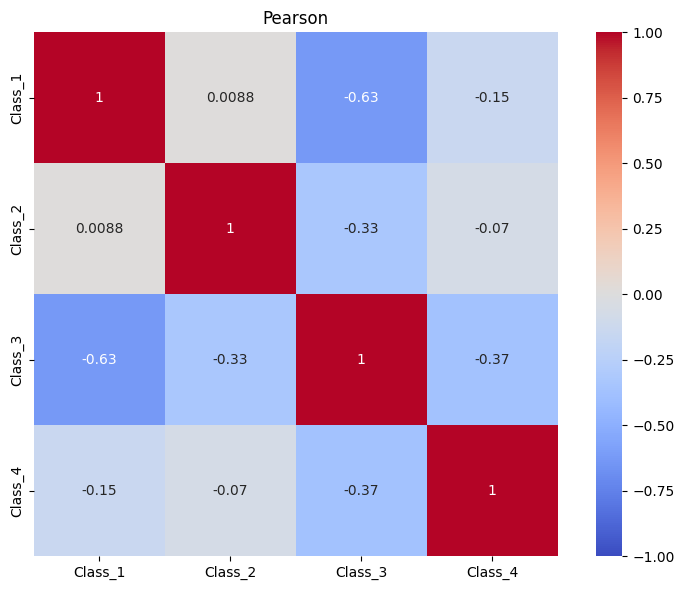

In [11]:
class_presence = df_pivot[['Class_1', 'Class_2', 'Class_3', 'Class_4']].notna().astype(int)
corr = class_presence.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Pearson')
plt.tight_layout()
plt.savefig('eda_correlation.png')
plt.show()

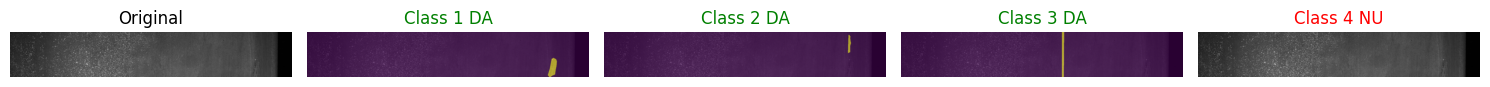

In [12]:
def show_sample(img_id):
    img = cv2.imread(os.path.join(TRAIN_DIR, img_id))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    row = df_pivot[df_pivot['ImageId'] == img_id].iloc[0]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')

    for i in range(1, 5):
        mask = rle_decode(row[f'Class_{i}'])
        axes[i].imshow(img)
        if mask.max() > 0:
            axes[i].imshow(mask, alpha=0.6)
            axes[i].set_title(f'Class {i} DA', color='green')
        else:
            axes[i].set_title(f'Class {i} NU', color='red')
        axes[i].axis('off')
    plt.tight_layout()
    return fig

multi_defect = df_pivot[df_pivot['num_defects'] >= 3]['ImageId'].values
if len(multi_defect) > 0:
    show_sample(multi_defect[0])
    plt.savefig('eda_sample_multi.png')
    plt.show()

# **2. Data prep, utils & metrics**

In [49]:
train_ids, val_ids = train_test_split(df_pivot['ImageId'].values, train_size=0.8, test_size=0.2)
print(f"\nTrain: {len(train_ids)}, Val: {len(val_ids)}")


Train: 5332, Val: 1334


In [145]:
class SteelDatasetSegmentation(Dataset):
    """For Segformer, SAM, DINOv2 (multi-class segmentation)"""
    def __init__(self, image_ids, df, image_dir, transform=None, image_size=512):
        self.image_ids = image_ids
        self.df_dict = df.set_index('ImageId').to_dict('index')  # O(1)
        self.image_dir = image_dir
        self.transform = transform
        self.image_size = image_size

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.image_dir, img_id)
    
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
        row = self.df_dict[img_id]
        masks = []
        for i in range(1, 5):
            mask = rle_decode(row[f'Class_{i}'])
            masks.append(mask)
        masks = np.stack(masks, axis=-1)  # (H, W, C)
    
        if self.transform:
            transformed = self.transform(image=image, mask=masks)
            image = transformed['image']         
            masks = transformed['mask']          
            if isinstance(masks, torch.Tensor):
                masks = masks.permute(2,0,1).float()  # [C,H,W]
            else:
                masks = torch.from_numpy(masks).permute(2,0,1).float()
        else:
            image = torch.from_numpy(image).permute(2,0,1).float()
            masks = torch.from_numpy(masks).permute(2,0,1).float()
    
        return image, masks

In [119]:
class SteelDatasetMaskRCNN(Dataset):
    def __init__(self, df, img_folder, img_size=(256,1600)):
        self.df = df
        self.img_folder = img_folder
        self.grouped = df.groupby('ImageId')   
        self.image_ids = list(self.grouped.groups.keys())  # list of unique img id's
        self.img_size = img_size

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        rows = self.grouped.get_group(img_id)

        image = cv2.imread(f"{self.img_folder}/{img_id}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)      # read image

        masks = []
        boxes = []
        labels = []

        # Append masks boxes and labels
        for _, row in rows.iterrows():
            mask = RLE_to_mask(row['EncodedPixels'])
            masks.append(mask)

            pos = np.where(mask)
            xmin, xmax = np.min(pos[1]), np.max(pos[1])
            ymin, ymax = np.min(pos[0]), np.max(pos[0])

            xmax = max(xmax, xmin + 1)
            ymax = max(ymax, ymin + 1)

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(row['ClassId']) 

        # Create dict
        target = {      
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "masks": torch.as_tensor(np.stack(masks), dtype=torch.uint8)
        }
        
        image = torch.from_numpy(image).permute(2,0,1).float() / 255.0

        return image, target

def collate_fn(batch):      # creates a tuple of dicts
    return tuple(zip(*batch))

In [76]:
# Store [Img.png (3,256,1600), and a tensor masks (4,256,1600)]
class SteelDataset(Dataset):
    def __init__(self, df, img_folder):
        self.img_folder = img_folder
        self.grouped = df.groupby('ImageId')   
        self.image_ids = list(self.grouped.groups.keys())  # list of unique img id's

    def __len__(self):
        return len(self.image_ids)  

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        rows = self.grouped.get_group(image_id)     # get RLE encoding

        image = cv2.imread(f"{self.img_folder}/{image_id}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # read image

        mask = np.zeros((4, 256, 1600), dtype=np.float32) # create 4 empty masks

        for _, row in rows.iterrows():  # itterates through rle's (you can have multiple rows with the same image id)
            if pd.notna(row['EncodedPixels']):
                class_id = int(row['ClassId']) - 1
                mask[class_id] = rle_decode(row['EncodedPixels']) # applies mask 

        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).float()

        return image, mask

In [53]:
# transformari imageinet: https://stackoverflow.com/questions/58151507/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-2/60179019
# https://docs.pytorch.org/vision/main/models.html

def get_train_transform(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_val_transform(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

In [54]:
def dice_coefficient(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return (2. * intersection + smooth) / (union + smooth).mean()

def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    return (intersection + smooth) / (union + smooth).mean()

In [55]:
class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.7):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        pred_sigmoid = torch.sigmoid(pred)
        dice_loss = 1 - dice_coefficient(pred_sigmoid, target)
        bce_loss = self.bce(pred, target)
        return self.dice_weight * dice_loss + (1 - self.dice_weight) * bce_loss

In [60]:
from tqdm import tqdm

def train_fn(epochs, train_loader, net, optimizer):
    net.to(device) 
    
    for epoch in range(epochs):
        net.train()
        epoch_loss = 0
        
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)
        
        for images, targets in loop:
            images = images.to(device)
            targets = targets.to(device)

            outputs = net(images)

            loss = loss_fn(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()

            # update live in bar (asta conteaza, nu doar tqdm gol)
            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch} | Avg Loss: {epoch_loss/len(train_loader):.4f}")

# **3. U-Net**

In [57]:
df = pd.read_csv(TRAIN_CSV)
df.columns = ["ImageId", "ClassId", "EncodedPixels"]

steel_data = SteelDataset(df,TRAIN_DIR)
train_loader = DataLoader(steel_data, batch_size=4, shuffle=True)

u_net = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",    
    in_channels=3,                  
    classes=4,                     
    activation= None          
)

optimizer = optim.AdamW(u_net.parameters(), lr=1e-4, weight_decay=1e-2)
loss_fn = smp.losses.DiceLoss(mode='multilabel')

In [62]:
train_fn(1, train_loader, u_net, optimizer)
torch.save(u_net.state_dict(), 'u-net_model.pth')

Epoch 0 | Avg Loss: 0.3235


# **4. YOLO 11**

In [5]:
model = YOLO("yolo11n.pt")
results = model.train(data="/kaggle/input/datasets/rarescocosila/steel-defect-detection/yolo.yaml", 
                      epochs=5, imgsz=512, batch = 16, device="cuda:0")

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/rarescocosila/steel-defect-detection/yolo.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

# **5. Mask R-CNN**

In [102]:
df = pd.read_csv(TRAIN_CSV)
df.columns = ["ImageId", "ClassId", "EncodedPixels"]

steel_data = SteelDatasetMaskRCNN(df, img_folder=TRAIN_DIR, img_size=(256,1600))
train_loader = DataLoader(steel_data, batch_size=2, shuffle=True, collate_fn=collate_fn)

optimizer = optim.AdamW(maskRcnn_model.parameters(), lr=1e-4, weight_decay=1e-2)

def train(model, loader, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0

        # images = Batch of images
        # targests = Batch of dict's
        for images, targets in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images = [img.to(device) for img in images]
            targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            total_loss += losses.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f}")

In [100]:
maskRcnn_model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

# 4 defects + background
num_classes = 5

# Box predictor
in_features = maskRcnn_model.roi_heads.box_predictor.cls_score.in_features
maskRcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Mask predictor
in_features_mask = maskRcnn_model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
maskRcnn_model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

maskRcnn_model.to(device)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [103]:
train(maskRcnn_model, train_loader, optimizer, epochs=1)
torch.save(maskRcnn_model.state_dict(), 'maskRcnn_model.pth')

Epoch 1/1:   0%|          | 0/3333 [00:00<?, ?it/s]

Epoch 1/1 | Loss: 0.5353


# **6. ViT**

In [146]:
train_dataset_vit = SteelDatasetSegmentation(train_ids, df_pivot, TRAIN_DIR, get_train_transform(512), 512)
val_dataset_vit = SteelDatasetSegmentation(val_ids, df_pivot, TRAIN_DIR, get_val_transform(512), 512)

train_loader_vit = DataLoader(train_dataset_vit, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader_vit = DataLoader(val_dataset_vit, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

model_vit = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/segformer-b0-finetuned-ade-512-512',
    num_labels=4,
    ignore_mismatched_sizes=True
).to(device)

n_params_vit = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
print(f"Segformer parameters: {n_params_vit:,}")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([4])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Segformer parameters: 3,715,172


In [147]:
criterion_vit = DiceBCELoss()
optimizer_vit = torch.optim.AdamW(model_vit.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_vit = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=1)
scaler_vit = GradScaler() if USE_AMP and device == 'cuda' else None

/tmp/ipykernel_55/3584331850.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_vit = GradScaler() if USE_AMP and device == 'cuda' else None


In [148]:
best_dice_vit = 0
patience_counter_vit = 0
history_vit = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

for epoch in range(30):
    # Train
    model_vit.train()
    train_loss = 0

    for images, masks in tqdm(train_loader_vit, desc=f'ViT Epoch {epoch+1}/{30}'):
        images, masks = images.to(device), masks.to(device)
        optimizer_vit.zero_grad()

        if scaler_vit:
            with autocast():
                outputs = model_vit(pixel_values=images).logits
                outputs = nn.functional.interpolate(outputs, size=masks.shape[-2:],mode='bilinear', align_corners=False)
                print(outputs.shape, masks.shape)
                loss = criterion_vit(outputs, masks)
            scaler_vit.scale(loss).backward()
            scaler_vit.step(optimizer_vit)
            scaler_vit.update()
        else:
            outputs = model_vit(pixel_values=images).logits
            outputs = nn.functional.interpolate(outputs, size=masks.shape[-2:],mode='bilinear', align_corners=False)
            print(outputs.shape, masks.shape)
            loss = criterion_vit(outputs, masks)
            loss.backward()
            optimizer_vit.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_vit)
    history_vit['train_loss'].append(train_loss)

    # Validate
    model_vit.eval()
    val_loss = val_dice = val_iou = 0

    with torch.no_grad():
        for images, masks in val_loader_vit:
            images, masks = images.to(device), masks.to(device)

            if scaler_vit:
                with autocast():
                    outputs = model_vit(pixel_values=images).logits
                    outputs = nn.functional.interpolate(outputs, size=masks.shape[-2:],
                                                        mode='bilinear', align_corners=False)
                    loss = criterion_vit(outputs, masks)
            else:
                outputs = model_vit(pixel_values=images).logits
                outputs = nn.functional.interpolate(outputs, size=masks.shape[-2:],
                                                    mode='bilinear', align_corners=False)
                loss = criterion_vit(outputs, masks)

            val_loss += loss.item()
            preds = torch.sigmoid(outputs)
            val_dice += dice_coefficient(preds, masks).item()
            val_iou += iou_score(preds, masks).item()

    val_loss /= len(train_loader_vit)
    val_dice /= len(val_loader_vit)
    val_iou /= len(val_loader_vit)

    history_vit['val_loss'].append(val_loss)
    history_vit['val_dice'].append(val_dice)
    history_vit['val_iou'].append(val_iou)

    scheduler_vit.step()

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}/{val_loss:.4f}, Dice={val_dice:.4f}, IoU={val_iou:.4f}")

    # Early stopping
    if val_dice > best_dice_vit:
        best_dice_vit = val_dice
        torch.save(model_vit.state_dict(), 'segformer_best.pth')
        print(f"  Best saved (Dice: {best_dice_vit:.4f})")
        patience_counter_vit = 0
    else:
        patience_counter_vit += 1
        if patience_counter_vit >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

ViT Epoch 1/30:   0%|          | 0/1333 [00:00<?, ?it/s]

torch.Size([4, 4, 512, 512]) torch.Size([4, 4, 512, 512])


/tmp/ipykernel_55/2247418479.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


RuntimeError: grad can be implicitly created only for scalar outputs

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_vit['train_loss'], label='Train')
axes[0].plot(history_vit['val_loss'], label='Val')
axes[0].set_title('Segformer Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_vit['val_dice'], label='Dice', color='green')
axes[1].plot(history_vit['val_iou'], label='IoU', color='blue')
axes[1].set_title('Segformer Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('segformer_training.png')
plt.show()

print(f"\nSegformer Results: Best Dice={best_dice_vit:.4f}, Epochs={len(history_vit['train_loss'])}")

# **7. SAM + cnn head**

In [ ]:
train_dataset_sam = SteelDatasetSegmentation(train_ids, df_pivot, TRAIN_DIR, get_train_transform(1024), 1024)
val_dataset_sam = SteelDatasetSegmentation(val_ids, df_pivot, TRAIN_DIR, get_val_transform(1024), 1024)

train_loader_sam = DataLoader(train_dataset_sam, batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader_sam = DataLoader(val_dataset_sam, batch_size=2, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
sam_base = sam_model_registry['vit_b'](checkpoint=SAM_CHECKPOINT).to(device)

# Freeze encoder
for param in sam_base.image_encoder.parameters():
    param.requires_grad = False

class SAMDefectHead(nn.Module):
    def __init__(self, sam_model, num_classes=4):
        super().__init__()
        self.sam = sam_model
        self.head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, num_classes, 1)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.sam.image_encoder(x)
        out = self.head(features)
        return nn.functional.interpolate(out, size=(1024, 1024),
                                         mode='bilinear', align_corners=False)

model_sam = SAMDefectHead(sam_base, NUM_CLASSES).to(device)
n_params_sam = sum(p.numel() for p in model_sam.parameters() if p.requires_grad)
print(f"SAM parameters: {n_params_sam:,}")

In [ ]:
criterion_sam = DiceBCELoss()
optimizer_sam = torch.optim.AdamW(model_sam.head.parameters(), lr=LR_SAM, weight_decay=1e-4)
scheduler_sam = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_sam, T_max=EPOCHS_SAM)
scaler_sam = GradScaler() if USE_AMP and device == 'cuda' else None

In [ ]:
best_dice_sam = 0
patience_counter_sam = 0
history_sam = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

for epoch in range(EPOCHS_SAM):
    # Train
    model_sam.train()
    train_loss = 0

    for images, masks in tqdm(train_loader_sam, desc=f'SAM Epoch {epoch+1}/{EPOCHS_SAM}'):
        images, masks = images.to(device), masks.to(device)
        optimizer_sam.zero_grad()

        if scaler_sam:
            with autocast():
                outputs = model_sam(images)
                loss = criterion_sam(outputs, masks)
            scaler_sam.scale(loss).backward()
            scaler_sam.step(optimizer_sam)
            scaler_sam.update()
        else:
            outputs = model_sam(images)
            loss = criterion_sam(outputs, masks)
            loss.backward()
            optimizer_sam.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_sam)
    history_sam['train_loss'].append(train_loss)

    # Validate
    model_sam.eval()
    val_loss = val_dice = val_iou = 0

    with torch.no_grad():
        for images, masks in val_loader_sam:
            images, masks = images.to(device), masks.to(device)

            if scaler_sam:
                with autocast():
                    outputs = model_sam(images)
                    loss = criterion_sam(outputs, masks)
            else:
                outputs = model_sam(images)
                loss = criterion_sam(outputs, masks)

            val_loss += loss.item()
            preds = torch.sigmoid(outputs)
            val_dice += dice_coefficient(preds, masks).item()
            val_iou += iou_score(preds, masks).item()

    val_loss /= len(val_loader_sam)
    val_dice /= len(val_loader_sam)
    val_iou /= len(val_loader_sam)

    history_sam['val_loss'].append(val_loss)
    history_sam['val_dice'].append(val_dice)
    history_sam['val_iou'].append(val_iou)

    scheduler_sam.step()

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}/{val_loss:.4f}, Dice={val_dice:.4f}, IoU={val_iou:.4f}")

    # Early stopping
    if val_dice > best_dice_sam:
        best_dice_sam = val_dice
        torch.save(model_sam.state_dict(), 'sam_best.pth')
        print(f"  Best saved (Dice: {best_dice_sam:.4f})")
        patience_counter_sam = 0
    else:
        patience_counter_sam += 1
        if patience_counter_sam >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_sam['train_loss'], label='Train')
axes[0].plot(history_sam['val_loss'], label='Val')
axes[0].set_title('SAM Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_sam['val_dice'], label='Dice', color='green')
axes[1].plot(history_sam['val_iou'], label='IoU', color='blue')
axes[1].set_title('SAM Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('sam_training.png')
plt.show()

print(f"\nSAM Results: Best Dice={best_dice_sam:.4f}, Epochs={len(history_sam['train_loss'])}")

# **8. Dyno**

In [ ]:
dinov2_base = AutoModel.from_pretrained('facebook/dinov2-base')

class DINOv2Segmentation(nn.Module):
    def __init__(self, backbone, num_classes=4):
        super().__init__()
        self.backbone = backbone

        self.decode = nn.Sequential(
            nn.ConvTranspose2d(768, 384, 2, 2),
            nn.BatchNorm2d(384),
            nn.ReLU(),
            nn.ConvTranspose2d(384, 192, 2, 2),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.ConvTranspose2d(192, 96, 2, 2),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.Conv2d(96, num_classes, 1)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        outputs = self.backbone(x, output_hidden_states=True)
        features = outputs.last_hidden_state[:, 1:, :]  # remove CLS token

        # Reshape to spatial grid
        patch_h = patch_w = int(np.sqrt(features.shape[1]))
        features = features.reshape(B, patch_h, patch_w, -1).permute(0, 3, 1, 2)

        out = self.decode(features)
        return nn.functional.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)

model_dino = DINOv2Segmentation(dinov2_base, NUM_CLASSES).to(device)
n_params_dino = sum(p.numel() for p in model_dino.parameters() if p.requires_grad)
print(f"DINOv2 parameters: {n_params_dino:,}")

In [ ]:
criterion_dino = DiceBCELoss()
optimizer_dino = torch.optim.AdamW(model_dino.parameters(), lr=LR_DINO, weight_decay=1e-4)
scheduler_dino = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_dino, T_max=EPOCHS_DINO)
scaler_dino = GradScaler() if USE_AMP and device == 'cuda' else None

In [ ]:
best_dice_dino = 0
patience_counter_dino = 0
history_dino = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

for epoch in range(EPOCHS_DINO):
    # Train
    model_dino.train()
    train_loss = 0

    for images, masks in tqdm(train_loader_dino, desc=f'DINO Epoch {epoch+1}/{EPOCHS_DINO}'):
        images, masks = images.to(device), masks.to(device)
        optimizer_dino.zero_grad()

        if scaler_dino:
            with autocast():
                outputs = model_dino(images)
                loss = criterion_dino(outputs, masks)
            scaler_dino.scale(loss).backward()
            scaler_dino.step(optimizer_dino)
            scaler_dino.update()
        else:
            outputs = model_dino(images)
            loss = criterion_dino(outputs, masks)
            loss.backward()
            optimizer_dino.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_dino)
    history_dino['train_loss'].append(train_loss)

    # Validate
    model_dino.eval()
    val_loss = val_dice = val_iou = 0

    with torch.no_grad():
        for images, masks in val_loader_dino:
            images, masks = images.to(device), masks.to(device)

            if scaler_dino:
                with autocast():
                    outputs = model_dino(images)
                    loss = criterion_dino(outputs, masks)
            else:
                outputs = model_dino(images)
                loss = criterion_dino(outputs, masks)

            val_loss += loss.item()
            preds = torch.sigmoid(outputs)
            val_dice += dice_coefficient(preds, masks).item()
            val_iou += iou_score(preds, masks).item()

    val_loss /= len(val_loader_dino)
    val_dice /= len(val_loader_dino)
    val_iou /= len(val_loader_dino)

    history_dino['val_loss'].append(val_loss)
    history_dino['val_dice'].append(val_dice)
    history_dino['val_iou'].append(val_iou)

    scheduler_dino.step()

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}/{val_loss:.4f}, Dice={val_dice:.4f}, IoU={val_iou:.4f}")

    # Early stopping
    if val_dice > best_dice_dino:
        best_dice_dino = val_dice
        torch.save(model_dino.state_dict(), 'dinov2_best.pth')
        print(f"  Best saved (Dice: {best_dice_dino:.4f})")
        patience_counter_dino = 0
    else:
        patience_counter_dino += 1
        if patience_counter_dino >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_dino['train_loss'], label='Train')
axes[0].plot(history_dino['val_loss'], label='Val')
axes[0].set_title('DINOv2 Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_dino['val_dice'], label='Dice', color='green')
axes[1].plot(history_dino['val_iou'], label='IoU', color='blue')
axes[1].set_title('DINOv2 Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('dinov2_training.png')
plt.show()